<a href="https://colab.research.google.com/github/JustusAkuku/Codveda-Technologies-Internship/blob/main/Neural_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading and Inspection

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/churn-bigml-80.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)

Mounted at /content/drive
Dataset loaded successfully
Shape: (2666, 20)


In [2]:
#First 5 rows
df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [3]:
# Check and remove missing values and duplicates
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
df.drop_duplicates(inplace=True)

Missing values: 0
Duplicate rows: 0


## Data Preprocessing

In [4]:
# Convert binary categorical features to numerical (0 and 1)
df['International plan'] = df['International plan'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Voice mail plan'] = df['Voice mail plan'].apply(lambda x: 1 if x == 'Yes' else 0)
df['Churn'] = df['Churn'].apply(lambda x: 1 if x == True else 0)

print("Converted 'International plan', 'Voice mail plan', and 'Churn' to numerical.")

Converted 'International plan', 'Voice mail plan', and 'Churn' to numerical.


In [5]:
# One-hot encode 'State' and 'Area code' (if needed, otherwise drop 'Area code')
# For simplicity, let's one-hot encode 'State' and check unique values for 'Area code'
print(f"Unique 'Area code' values: {df['Area code'].nunique()}")

# If 'Area code' has many unique values, it might be better to drop it or treat it differently.
# Given the dataset, 'Area code' usually represents geographical regions which can be treated as categorical.
# Let's one-hot encode both 'State' and 'Area code'
df = pd.get_dummies(df, columns=['State', 'Area code'], drop_first=True)

print("One-hot encoded 'State' and 'Area code'.")
display(df.head())

Unique 'Area code' values: 3
One-hot encoded 'State' and 'Area code'.


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area code_415,Area code_510
0,128,0,1,25,265.1,110,45.07,197.4,99,16.78,...,False,False,False,False,False,False,False,False,True,False
1,107,0,1,26,161.6,123,27.47,195.5,103,16.62,...,False,False,False,False,False,False,False,False,True,False
2,137,0,0,0,243.4,114,41.38,121.2,110,10.30,...,False,False,False,False,False,False,False,False,True,False
3,84,1,0,0,299.4,71,50.90,61.9,88,5.26,...,False,False,False,False,False,False,False,False,False,False
4,75,1,0,0,166.7,113,28.34,148.3,122,12.61,...,False,False,False,False,False,False,False,False,True,False


In [6]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Separate features (X) and target (y)
X = df.drop('Churn', axis=1)
y = df['Churn']

# Identify numerical columns for scaling
numerical_cols = X.select_dtypes(include=np.number).columns.tolist()

# Exclude columns that are already binary or one-hot encoded and 'Account length', 'Number vmail messages', 'Customer service calls'
# We should only scale columns that represent continuous numerical values or counts.
columns_to_exclude_from_scaling = [
    'International plan', 'Voice mail plan',
    'Account length', 'Number vmail messages', 'Customer service calls'
]

# Filter numerical columns to only include those that are not binary or counts that might not benefit from scaling initially
actual_numerical_cols_to_scale = [col for col in numerical_cols if col not in columns_to_exclude_from_scaling and not col.startswith(('State_', 'Area code_'))]

scaler = StandardScaler()
X[actual_numerical_cols_to_scale] = scaler.fit_transform(X[actual_numerical_cols_to_scale])

print("Scaled numerical features.")
display(X.head())

Scaled numerical features.


,Account length,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,...,State_TX,State_UT,State_VA,State_VT,State_WA,State_WI,State_WV,State_WY,Area code_415,Area code_510
0,128,0,1,25,1.579670,0.484868,1.579942,-0.058619,-0.050781,-0.058445,...,False,False,False,False,False,False,False,False,True,False
1,107,0,1,26,-0.329918,1.135375,-0.330194,-0.095916,0.147654,-0.095397,...,False,False,False,False,False,False,False,False,True,False
2,137,0,0,0,1.179302,0.685024,1.179465,-1.554439,0.494917,-1.554963,...,False,False,False,False,False,False,False,False,True,False
3,84,1,0,0,2.212509,-1.466653,2.212675,-2.718509,-0.596479,-2.718922,...,False,False,False,False,False,False,False,False,False,False
4,75,1,0,0,-0.235822,0.634985,-0.235772,-1.022461,1.090224,-1.021482,...,False,False,False,False,False,False,False,False,True,False


In [7]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("Data split into training and testing sets.")

X_train shape: (2132, 69)
X_test shape: (534, 69)
y_train shape: (2132,)
y_test shape: (534,)
Data split into training and testing sets.


## Neural Network Architecture (Keras)

In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Define the model
model = keras.Sequential([
    layers.Input(shape=(X_train.shape[1],)),  # Input layer with number of features
    layers.Dense(128, activation='relu', name='hidden_layer_1'),
    layers.Dropout(0.2), # Dropout for regularisation
    layers.Dense(64, activation='relu', name='hidden_layer_2'),
    layers.Dropout(0.2), # Dropout for regularisation
    layers.Dense(1, activation='sigmoid', name='output_layer') # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

# Display the model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 128)            │         8,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden_layer_2 (Dense)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,281 (67.50 KB)

 Trainable params: 17,281 (67.50 KB)

 Non-trainable params: 0 (0.00 B)

## Model Training

In [9]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=50,  # You can adjust the number of epochs
                    batch_size=32, # You can adjust the batch size
                    validation_data=(X_test, y_test),
                    verbose=1)

print("Model training complete.")

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7617 - loss: 1.0164 - val_accuracy: 0.8539 - val_loss: 0.4342
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8035 - loss: 0.5761 - val_accuracy: 0.8539 - val_loss: 0.4340
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8433 - loss: 0.4734 - val_accuracy: 0.8539 - val_loss: 0.4384
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8494 - loss: 0.4541 - val_accuracy: 0.8539 - val_loss: 0.4330
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8532 - loss: 0.4395 - val_accuracy: 0.8539 - val_loss: 0.4234
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8555 - loss: 0.4245 - val_accuracy: 0.8539 - val_loss: 0.4220
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8560 - loss: 0.4175 - val_accuracy: 0.8539 - val_loss: 0.4171
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8560 - loss: 0.4142 - val_accuracy: 0.8539 - val_loss:

## Model Evaluation and Visualization

In [10]:
# Evaluate the model on the test data
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test Loss: {loss:.4f}")


Test Accuracy: 0.8914
Test Loss: 0.4021


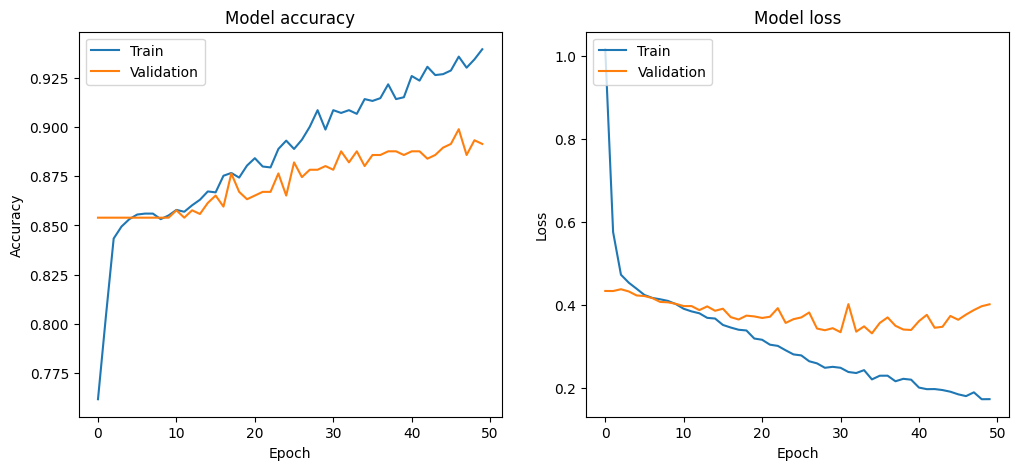

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


## Hyperparameter Tuning with Keras Tuner

In [12]:
!pip install keras_tuner --upgrade

print("Keras Tuner installed. Please re-run the subsequent cells to perform hyperparameter tuning.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.4/129.4 kB 4.4 MB/s eta 0:00:00
Keras Tuner installed. Please re-run the subsequent cells to perform hyperparameter tuning.


In [13]:
import keras_tuner as kt

# Define the build_model function required by Keras Tuner
def build_model(hp):
    model = keras.Sequential()
    model.add(layers.Input(shape=(X_train.shape[1],)))

    # Tune the number of units in the first Dense layer
    hp_units_1 = hp.Int('units_1', min_value=32, max_value=256, step=32)
    model.add(layers.Dense(units=hp_units_1, activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout_1', min_value=0.0, max_value=0.5, step=0.1)))

    # Tune the number of units in the second Dense layer
    hp_units_2 = hp.Int('units_2', min_value=32, max_value=128, step=32)
    model.add(layers.Dense(units=hp_units_2, activation='relu'))
    model.add(layers.Dropout(hp.Float('dropout_2', min_value=0.0, max_value=0.5, step=0.1)))

    model.add(layers.Dense(1, activation='sigmoid'))

    # Tune the learning rate for the optimizer
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-2, 1e-3, 1e-4])
    optimizer = keras.optimizers.Adam(learning_rate=hp_learning_rate)

    model.compile(optimizer=optimizer,
                  loss='binary_crossentropy',
                  metrics=['accuracy'])
    return model

print("Keras model building function defined.")

Keras model building function defined.


In [14]:
# Initialize the Keras Tuner Hyperband tuner
tuner = kt.Hyperband(
    build_model,
    objective='val_accuracy',
    max_epochs=50,  # Maximum number of epochs to train a model
    factor=3,       # Factor by which to reduce the number of epochs for successive brackets
    directory='my_dir',
    project_name='churn_prediction_tuning',
    overwrite=True
)

print("Keras Tuner Hyperband tuner initialized.")

Keras Tuner Hyperband tuner initialized.


In [15]:
# Define callbacks for the tuner search
stop_early = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)

# Perform the hyperparameter search
# We will also tune the batch_size here by passing it to the fit method of the tuner search
# We'll use a fixed batch_size for the tuner search for simplicity, and note it as a point for further manual tuning if needed.
# For this demonstration, we will use a batch_size of 32 for the tuner's internal training runs.

tuner.search(X_train, y_train,
             epochs=50, # Max epochs for a single trial, tuner will use max_epochs specified in Hyperband
             validation_data=(X_test, y_test),
             callbacks=[stop_early],
             verbose=1)

print("Hyperparameter search complete.")

Trial 90 Complete [00h 00m 09s]
val_accuracy: 0.8539325594902039

Best val_accuracy So Far: 0.898876428604126
Total elapsed time: 00h 08m 30s
Hyperparameter search complete.


In [16]:
# Get the optimal hyperparameters
best_hps = tuner.get_best_hyperparameters(num_trials=1)[0]

print(f"Optimal learning rate: {best_hps.get('learning_rate')}")
print(f"Optimal units in first layer: {best_hps.get('units_1')}")
print(f"Optimal units in second layer: {best_hps.get('units_2')}")
print(f"Optimal dropout rate for first layer: {best_hps.get('dropout_1')}")
print(f"Optimal dropout rate for second layer: {best_hps.get('dropout_2')}")

# Build the best model and train it
best_model = tuner.get_best_models(num_models=1)[0]

print("Best model built from optimal hyperparameters.")

# Evaluate the best model on the test data
loss, accuracy = best_model.evaluate(X_test, y_test, verbose=0)
print(f"Best Model Test Accuracy: {accuracy:.4f}")
print(f"Best Model Test Loss: {loss:.4f}")

Optimal learning rate: 0.01
Optimal units in first layer: 64
Optimal units in second layer: 96
Optimal dropout rate for first layer: 0.1
Optimal dropout rate for second layer: 0.4
Best model built from optimal hyperparameters.


/usr/local/lib/python3.13/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


Best Model Test Accuracy: 0.8989
Best Model Test Loss: 0.2892
